# Red neuronal artificial para reconocer el tipo de un pokemon

En esta tarea ustedes deben diseñar, entrenar y evaluar un modelo de red neuronal con arquitectura convolucional para resolver el problema de reconocer el tipo de un pokemon en base a una imagen del mismo y a sus atributos. El principal desafio es el desbalance y poca cantidad de ejemplos en el dataset. 

A continuación se instancia el dataset y se itera para presentar algunos ejemplos:

In [3]:
%pip install torchvision

  Using cached torchvision-0.27.0-cp314-cp314-macosx_14_0_arm64.whl.metadata (5.5 kB)
Using cached torchvision-0.27.0-cp314-cp314-macosx_14_0_arm64.whl (1.8 MB)

[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


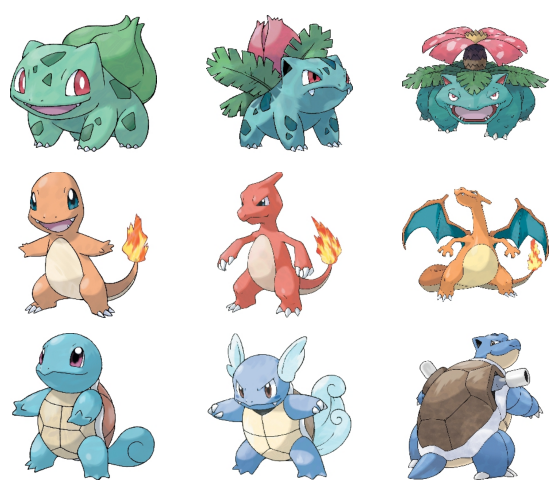

In [4]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
import matplotlib.pyplot as plt
from pokemon_utils import PokemonImages

dataset = PokemonImages('data/')

fig, ax = plt.subplots(3, 3, figsize=(7, 5), tight_layout=True)
for ax_, (image, label, name, attributes) in zip(ax.ravel(), dataset):
    ax_.imshow(image.permute(-2, -1, 0))
    ax_.axis('off');

Cada ejemplo tiene su imagen, su etiqueta, su nombre y sus atributos:

In [6]:
image, label, name, attributes = dataset[0]
type(image), image.shape, label, name, attributes

(torch.Tensor,
 torch.Size([3, 256, 256]),
 np.int64(9),
 'Bulbasaur',
 tensor([ 0.7000,  6.9000, 45.0000, 49.0000, 49.0000, 45.0000]))

Se puede obtener el nombre de la clase con:

In [7]:
dataset.categories[label]

'Grass'

Y los atributos disponibles son:

In [8]:
dataset.attribute_names

['Height', 'Weight', 'HP', 'Attack', 'Defense', 'Speed']

La cantidad de ejemplos por clase es:

In [9]:
from collections import Counter
import pandas as pd
x = Counter(dataset.labels)
for key in sorted(x):
    print(f"{dataset.categories[key]}: {x[key]}")

Bug: 52
Dark: 20
Dragon: 13
Electric: 32
Fairy: 8
Fighting: 20
Fire: 34
Ghost: 18
Grass: 58
Ground: 26
Ice: 19
Normal: 80
Poison: 26
Psychic: 44
Rock: 32
Steel: 17
Water: 96


En lo que sigue utilice los siguientes conjuntos de entrenamiento (train) y prueba (test). 

In [10]:
import numpy as np
from torch.utils.data import Subset, DataLoader
from sklearn.model_selection import train_test_split

train_idx, test_idx = train_test_split(np.arange(len(dataset)),test_size=0.15, random_state=1234, 
                                       shuffle=True, stratify=dataset.labels)

train_dataset = Subset(dataset, train_idx)
test_dataset = Subset(dataset, test_idx)

# Definición del modelo

Se decidió utilizar una Red Neuronal Convolucional (CNN) inspirada en la arquitectura LeNet-5. Esta decisión se tomó debido a que el problema consiste en clasificar imágenes de Pokémon, y las redes convolucionales fueron diseñadas específicamente para procesar datos organizados como una grilla regular, como imágenes, series de tiempo y video. En particular, las CNN permiten aprender automáticamente filtros capaces de detectar bordes, formas, colores y patrones visuales relevantes presentes en las imágenes.

Se optó por una arquitectura inspirada en LeNet-5 debido a su simplicidad y efectividad para tareas de clasificación de imágenes. Aunque originalmente fue desarrollada para el reconocimiento de dígitos manuscritos, sus principios pueden aplicarse a cualquier problema de clasificación visual. Además, el conjunto de datos utilizado contiene aproximadamente 721 imágenes, por lo que una arquitectura excesivamente profunda podría aumentar el riesgo de sobreajuste. Por esta razón, se seleccionó una arquitectura relativamente simple, capaz de aprender características visuales relevantes sin requerir una gran cantidad de datos para su entrenamiento.

Durante el análisis del conjunto de datos se observó que existen 17 clases distintas correspondientes a los diferentes tipos de Pokémon presentes en el dataset. Esta información es importante para definir la arquitectura de la red, ya que determina el número de neuronas necesarias en la capa de salida.

## Arquitectura propuesta

```text
Entrada (Imagen)
        ↓
      Conv1
        ↓
      ReLU
        ↓
   MaxPooling
        ↓
      Conv2
        ↓
      ReLU
        ↓
   MaxPooling
        ↓
     Flatten
        ↓
 Fully Connected
        ↓
  Capa de Salida
```

## Descripción de cada componente

- Conv1: Corresponde a la primera capa convolucional. Su objetivo es detectar características visuales básicas presentes en la imagen, tales como bordes, contornos, cambios de color y texturas simples.

- ReLU: Corresponde a la función de activación ReLU (Rectified Linear Unit). Su función es introducir no linealidad en el modelo, permitiendo aprender relaciones más complejas entre las características visuales y las clases objetivo.

- MaxPooling: Esta capa reduce el tamaño de las representaciones internas generadas por la convolución, conservando la información más relevante. Esto disminuye el costo computacional y ayuda a reducir el riesgo de sobreajuste.

- Conv2: Corresponde a la segunda capa convolucional. A diferencia de la primera capa, que detecta patrones simples, esta capa combina dichas características para identificar estructuras visuales más complejas, como formas, texturas y patrones característicos de los Pokémon.

- Flatten: Transforma los mapas de activación obtenidos por las capas convolucionales en un vector unidimensional, permitiendo conectar la etapa de extracción de características con las capas de clasificación.

- Fully Connected: Corresponde a una capa completamente conectada encargada de combinar todas las características extraídas previamente y generar la predicción final de la clase.

- Capa de Salida: Entrega la clasificación final del tipo de Pokémon. Se utilizaron 17 neuronas de salida, una por cada clase presente en el conjunto de datos, permitiendo que la red asigne una probabilidad a cada tipo y seleccione la más probable como predicción final.

In [ ]:
#dimencionalidad de la imagen
# numero de clases
print(image.shape)
print(attributes.shape)

labels = [dataset[i][1] for i in range(len(dataset))]
print("Número de clases:", len(set(labels)))

torch.Size([3, 256, 256])
torch.Size([6])
Número de clases: 17


In [22]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class PokemonCNN(nn.Module):

    def __init__(self):

        super().__init__()

        # Conv1
        self.conv1 = nn.Conv2d(
            in_channels=3,
            out_channels=16,
            kernel_size=3,
            padding=1
        )

        # Conv2
        self.conv2 = nn.Conv2d(
            in_channels=16,
            out_channels=32,
            kernel_size=3,
            padding=1
        )

        # Conv3
        self.conv3 = nn.Conv2d(
            in_channels=32,
            out_channels=64,
            kernel_size=3,
            padding=1
        )

        self.pool = nn.MaxPool2d(2)

        self.flatten = nn.Flatten()

        # 64 × 32 × 32 + 6 atributos
        self.fc1 = nn.Linear(
            64 * 32 * 32 + 6,
            128
        )

        self.dropout = nn.Dropout(0.3)

        self.fc2 = nn.Linear(
            128,
            17
        )

    def forward(self, image, attributes):

        # Conv1
        x = self.pool(
            F.relu(
                self.conv1(image)
            )
        )

        # Conv2
        x = self.pool(
            F.relu(
                self.conv2(x)
            )
        )

        # Conv3
        x = self.pool(
            F.relu(
                self.conv3(x)
            )
        )

        # Flatten
        x = self.flatten(x)

        # Concatenar atributos
        x = torch.cat(
            [x, attributes],
            dim=1
        )

        # Fully Connected
        x = F.relu(
            self.fc1(x)
        )

        x = self.dropout(x)

        # Salida
        x = self.fc2(x)

        return x

### Entrenamiento del modelo

Entrene el modelo y muestre las curvas de aprendizaje. Justifique la elección de hiperparámetros.

### Evaluación del modelo

Evalúe el modelo en el conjunto de prueba usando matriz de confusión y reporte de clasificación. Discuta los resultados.

### Análisis de errores

Analice algunos ejemplos mal clasificados y comente lo que observa.

### Aumentación de datos

Implemente un esquema de aumentación aleatoria de datos y compare los resultados con y sin aumentación.